# Day 6 – End-to-End ML Pipeline & Business Insights

## Objective

Bring all individual ML components together and translate technical results into actionable business decisions.

This notebook integrates the outputs from:

1. Customer Segmentation
2. Restaurant Segmentation
3. Customer Feedback Sentiment Analysis
4. Delivery Time Prediction
5. Demand Forecasting

### End-to-End Flow

**Raw Data → Cleaning → Feature Engineering → Modeling → Evaluation → Prediction → Business Insight**

### Business Goal

Use the combined machine learning results to answer:

- Which customer segments are most valuable?
- Which restaurant segments require intervention?
- What are the biggest causes of negative customer experiences?
- Which factors contribute to delivery delays?
- What factors influence delivery performance?
- When should additional delivery capacity be deployed?
- Which time periods are likely to experience demand spikes?

The final objective is to translate model outputs into data-backed recommendations for improving customer experience, operational efficiency, and resource planning.

## Project ML Components

| Day | ML Component | Business Problem |
|---|---|---|
| Day 2 | Customer Segmentation | Understand customer behavior and value |
| Day 2 | Restaurant Segmentation | Identify restaurant performance groups |
| Day 3 | Sentiment Analysis | Understand customer satisfaction and complaints |
| Day 4 | Delivery Time Prediction | Predict and reduce delivery delays |
| Day 5 | Demand Forecasting | Predict future demand and plan capacity |

These models address different parts of the Uber Eats business and can be combined to support operational and strategic decisions.

## End-to-End ML Architecture

The project follows an end-to-end machine learning workflow:

**Data Collection**

↓  

**Data Cleaning & Validation**

↓

**Feature Engineering**

↓

**Exploratory Data Analysis**

↓

**Machine Learning Models**

↓

**Model Evaluation**

↓

**Predictions & Segmentation**

↓

**Business Insights**

↓

**Business Recommendations**

The individual ML models are developed separately for each business problem, while this notebook integrates their results into a unified business perspective.

## 1. Customer Segmentation

Customer segmentation was performed using behavioral features derived from customer ordering activity.

### Features Used

- Total Orders
- Average Order Value
- Total Spending
- Ordering Frequency
- Average Rating Given
- Weekend Orders
- Late-Night Orders

K-Means clustering identified two main customer groups.

### Customer Segments

| Segment | Customers | Avg Orders | Avg Order Value | Total Spending | Ordering Frequency | Weekend Orders | Late-Night Orders |
|---|---:|---:|---:|---:|---:|---:|---:|
| Occasional Moderate-Value Customers | 2,766 | 7.84 | 671.86 | 5,231.67 | 0.65 | 2.05 | 1.81 |
| Frequent High-Value Customers | 2,234 | 12.67 | 707.72 | 8,916.27 | 1.06 | 3.83 | 3.37 |

### Key Insight

The **Frequent High-Value Customers** segment represents 2,234 customers and shows substantially higher engagement and spending.

Compared with the Occasional Moderate-Value segment, these customers:

- Place more orders
- Have a slightly higher average order value
- Generate substantially higher total spending
- Order more frequently
- Place more weekend orders
- Place more late-night orders

This makes the Frequent High-Value segment an important customer group for retention and loyalty strategies.

### Business Implication

The Frequent High-Value Customer segment should be prioritized for retention because it generates higher order frequency and spending.

Potential actions include:

- Personalized offers
- Loyalty rewards
- Early access to promotions
- Retention campaigns
- Personalized restaurant recommendations

The objective should be to protect the existing value of this segment while encouraging Occasional Moderate-Value Customers to increase their ordering frequency.

## 2. Restaurant Segmentation

Restaurant segmentation was performed to identify groups of restaurants with similar operational and business characteristics.

The segmentation is intended to help the business distinguish between:

- High-performing restaurants
- Moderate-performing restaurants
- Restaurants requiring operational intervention

### Business Questions

The restaurant segmentation can be used to answer:

- Which restaurants contribute strongly to order activity and revenue?
- Which restaurants have lower performance?
- Which restaurants may require operational improvement?
- Which restaurant groups should receive different levels of support?

### Business Implication

Restaurant-level segmentation allows Uber Eats to move away from a one-size-fits-all strategy.

High-performing restaurants can be prioritized for retention and partnership programs, while lower-performing groups can be investigated for issues such as delivery performance, food quality, preparation time, or customer satisfaction.

> The specific restaurant segment characteristics and metrics should be taken directly from the Day 2 restaurant segmentation results.

## 3. Customer Feedback Analysis Using NLP

Natural Language Processing was used to understand customer sentiment and identify the major themes behind negative customer experiences.

### Sentiment Modeling

Two approaches were evaluated:

1. TF-IDF + Naive Bayes
2. VADER Sentiment Analysis

The traditional TF-IDF + Naive Bayes model achieved perfect classification performance on the evaluation set:

| Metric | Score |
|---|---:|
| Accuracy | 1.0000 |
| Precision | 1.0000 |
| Recall | 1.0000 |
| F1-score | 1.0000 |

VADER achieved:

| Metric | Score |
|---|---:|
| Accuracy | 0.8450 |
| Precision | 0.8252 |
| Recall | 0.8450 |
| F1-score | 0.8279 |

### Model Comparison

The TF-IDF + Naive Bayes approach performed substantially better on this dataset.

However, the perfect score should be interpreted carefully because the sentiment labels were derived from customer ratings. Therefore, the review text and target sentiment are strongly related by construction.

VADER was less accurate overall but provides a useful rule-based approach for short text where punctuation, emphasis, slang, and similar textual signals can influence sentiment.

### Negative Customer Experience Themes

The analysis identified the following major complaint themes:

- Packaging Issues
- Food Quality
- Poor Experience
- Delivery Delays

These themes provide actionable areas for operational improvement.

### Business Insight

Customer dissatisfaction is not driven by a single factor. The identified complaint themes indicate that Uber Eats should monitor both **restaurant-side quality** and **delivery-side performance**.

Reducing delivery delays, improving food quality, and addressing packaging issues can potentially improve the overall customer experience.

### Business Implication

The NLP analysis provides a direct connection between customer feedback and operational improvement.

The business should prioritize investigation of:

1. **Packaging issues** — work with restaurants to improve packaging standards.
2. **Food quality** — identify restaurants associated with recurring quality complaints.
3. **Delivery delays** — connect customer complaints with delivery-time and operational data.
4. **Poor overall experience** — investigate whether these reviews are associated with multiple service failures.

The most valuable next step is to connect these complaint themes with restaurant, delivery, and demand data to identify where interventions can have the greatest impact.

## 4. Delivery Time Prediction

Delivery duration was modeled as a supervised regression problem.

### Features Used

The model used operational, order, temporal, and categorical features including:

- Delivery distance
- Order amount
- Number of items
- Preparation time
- Restaurant/customer rating information
- Hour of day
- Day of week
- Weekend indicator
- Weather condition
- Traffic condition
- Time of day

The target variable was:

`delivery_duration_min`

### Model Comparison

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Linear Regression | 3.188 | 3.970 | 0.8992 |
| Random Forest | 3.403 | 4.237 | 0.8852 |
| Ridge | 3.188 | 3.970 | 0.8992 |
| Lasso | 3.188 | 3.970 | 0.8992 |

Lasso produced the lowest error by a very small margin, while Linear Regression and Ridge produced almost identical results.

Overall, the linear models performed better than Random Forest on this dataset.

### Key Insight

The delivery prediction models achieved an R² of approximately **0.90**, indicating that the selected features explain a large proportion of the variation in delivery duration.

The analysis also showed that **delivery distance, preparation time, traffic, and weather conditions** are important operational factors associated with delivery duration.

### Business Implication

Delivery-time prediction can be used as an operational planning tool.

When an order has characteristics associated with longer delivery times, the platform can use the prediction to:

- Improve estimated delivery times shown to customers
- Identify potentially delayed orders earlier
- Prioritize operational intervention
- Support rider allocation decisions
- Reduce unexpected delivery delays

This finding also connects directly with the NLP analysis, where **Delivery Delays** appeared as one of the major negative customer-experience themes.

Therefore, improving delivery-time prediction is not only a forecasting problem but also a customer-experience improvement opportunity.

## 5. Demand Forecasting

Hourly order demand was analyzed and forecasted to support operational capacity planning.

The analysis included:

- Hourly demand aggregation
- Daily and weekly time features
- Weekend analysis
- Peak-hour identification
- Seasonal decomposition
- Stationarity testing
- Chronological train/test splitting
- ARIMA forecasting
- Prophet forecasting
- Model comparison
- Future demand forecasting

### Model Comparison

Two forecasting approaches were evaluated:

- ARIMA
- Prophet

Prophet achieved the **lowest MAE**, while ARIMA achieved a **marginally lower RMSE**.

Therefore, Prophet was selected as the final forecasting model based on the primary MAE criterion.

The models performed similarly overall, so the difference should not be interpreted as a major superiority of one model over the other.

### Forecasting Output

The final Prophet model was trained using the available historical data and used to generate a **7-day future demand forecast**.

The forecast was also used to identify the hours expected to have the highest demand.

### Business Implication

Demand forecasting can support operational capacity planning.

The forecast can be used to:

- Identify upcoming high-demand periods
- Plan rider capacity
- Anticipate order-volume increases
- Support restaurant and delivery operations
- Reduce the risk of insufficient delivery capacity

The forecast should be combined with the delivery-time model.

When demand is expected to increase during a particular period, additional delivery capacity can be planned in advance to reduce the risk of longer delivery times.

## 6. Integrated ML Business View

The individual ML components provide complementary information.

### Customer Side

Customer segmentation identifies **who the most valuable customers are**.

### Restaurant Side

Restaurant segmentation identifies **which restaurant groups have different operational and business characteristics**.

### Experience Side

Sentiment analysis identifies **what customers are saying and what causes dissatisfaction**.

### Delivery Side

Delivery-time prediction identifies **which operational factors are associated with longer delivery times**.

### Demand Side

Demand forecasting identifies **when order volume is expected to increase**.

Together, these models provide a more complete view of the Uber Eats business than any individual model alone.

## 7. Integrated Model Comparison

The project contains several machine learning components, each addressing a different business problem.

### Customer Sentiment

| Approach | Accuracy | F1-score |
|---|---:|---:|
| TF-IDF + Naive Bayes | 1.0000 | 1.0000 |
| VADER | 0.8450 | 0.8279 |

### Delivery Time Prediction

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Linear Regression | 3.188 | 3.970 | 0.8992 |
| Random Forest | 3.403 | 4.237 | 0.8852 |
| Ridge | 3.188 | 3.970 | 0.8992 |
| Lasso | 3.188 | 3.970 | 0.8992 |

### Demand Forecasting

Two forecasting approaches were evaluated:

- ARIMA
- Prophet

Prophet achieved the lowest MAE, while ARIMA achieved a marginally lower RMSE. Prophet was therefore selected as the final forecasting model based on MAE.

### Interpretation

There is no single "best model" across the entire project because each model solves a different business problem.

The appropriate model should therefore be selected according to the objective:

- **Customer sentiment:** TF-IDF + Naive Bayes
- **Delivery duration:** Lasso / Linear Regression family
- **Demand forecasting:** Prophet based on MAE
- **Customer and restaurant segmentation:** K-Means provides interpretable behavioral groups, with DBSCAN providing additional outlier/density-based analysis

In [2]:

import pandas as pd
model_summary = pd.DataFrame({
    "Business Problem": [
        "Customer Sentiment",
        "Customer Sentiment",
        "Delivery Time",
        "Delivery Time",
        "Delivery Time",
        "Delivery Time"
    ],
    "Model": [
        "TF-IDF + Naive Bayes",
        "VADER",
        "Linear Regression",
        "Random Forest",
        "Ridge",
        "Lasso"
    ],
    "Primary Metric": [
        "Accuracy",
        "Accuracy",
        "MAE",
        "MAE",
        "MAE",
        "MAE"
    ],
    "Score": [
        1.0000,
        0.8450,
        3.187982,
        3.402696,
        3.187980,
        3.187644
    ]
})

display(model_summary)

,Business Problem,Model,Primary Metric,Score
0,Customer Sentiment,TF-IDF + Naive Bayes,Accuracy,1.000000
1,Customer Sentiment,VADER,Accuracy,0.845000
2,Delivery Time,Linear Regression,MAE,3.187982
3,Delivery Time,Random Forest,MAE,3.402696
4,Delivery Time,Ridge,MAE,3.187980
5,Delivery Time,Lasso,MAE,3.187644


## 8. Cross-Model Business Insights

The combined analysis reveals several connected business patterns.

### 1. Customer value

Frequent High-Value Customers generate substantially more orders and spending than Occasional Moderate-Value Customers.

This segment should therefore be an important focus for customer retention.

### 2. Customer experience

NLP identified Packaging Issues, Food Quality, Poor Experience, and Delivery Delays as major complaint themes.

This indicates that customer dissatisfaction is influenced by both restaurant-side and delivery-side operations.

### 3. Delivery operations

The delivery-time model achieved an R² of approximately 0.90.

Delivery distance, preparation time, traffic, and weather are important operational variables associated with delivery duration.

### 4. Demand and capacity

Demand forecasting provides information about upcoming periods of higher order volume.

Combining demand forecasts with delivery-time predictions provides a stronger operational planning framework than using either model independently.

### 5. Integrated view

The project therefore connects:

**Customer Value → Customer Experience → Restaurant Operations → Delivery Performance → Demand & Capacity**

In [3]:
import os

print(os.listdir("../data/processed"))

['customer_segmentation.csv', 'customer_features.csv', 'demand_forecast_7_days.csv', 'hourly_demand.csv', 'restaurant_segmentation.csv']


In [4]:
# Load Day 5 demand forecasting outputs

hourly_demand = pd.read_csv(
    "../data/processed/hourly_demand.csv"
)

demand_forecast = pd.read_csv(
    "../data/processed/demand_forecast_7_days.csv"
)

print("Hourly demand shape:", hourly_demand.shape)
print("7-day forecast shape:", demand_forecast.shape)

print("\nHourly demand columns:")
print(hourly_demand.columns.tolist())

print("\nForecast columns:")
print(demand_forecast.columns.tolist())

print("\n7-day forecast preview:")
display(demand_forecast.head())

Hourly demand shape: (8760, 5)
7-day forecast shape: (168, 4)

Hourly demand columns:
['order_timestamp', 'order_count', 'hour', 'day_of_week', 'is_weekend']

Forecast columns:
['forecast_timestamp', 'predicted_orders', 'lower_bound', 'upper_bound']

7-day forecast preview:


,forecast_timestamp,predicted_orders,lower_bound,upper_bound
0,2026-08-01 00:00:00,5.865879,2.735939,8.855825
1,2026-08-01 01:00:00,5.857208,2.710169,8.719812
2,2026-08-01 02:00:00,5.845116,2.753047,8.974902
3,2026-08-01 03:00:00,5.832649,2.885658,9.120201
4,2026-08-01 04:00:00,5.813418,2.915659,9.038552


In [5]:
# Inspect the actual demand forecast produced by Day 5

print("Forecast summary:")
display(demand_forecast.describe(include="all"))

print("\nForecast missing values:")
print(demand_forecast.isnull().sum())

Forecast summary:


,forecast_timestamp,predicted_orders,lower_bound,upper_bound
count,168,168.000000,168.000000,168.000000
unique,168,NaN,NaN,NaN
top,2026-08-01 00:00:00,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,5.791149,2.717454,8.836919
std,NaN,0.094657,0.168084,0.145829
min,NaN,5.599534,2.285087,8.345272
25%,NaN,5.726156,2.610593,8.736685
50%,NaN,5.781909,2.701820,8.821687
75%,NaN,5.859550,2.869434,8.936909



Forecast missing values:
forecast_timestamp    0
predicted_orders      0
lower_bound           0
upper_bound           0
dtype: int64


In [6]:
# Display the forecast output for business interpretation

display(
    demand_forecast
)

,forecast_timestamp,predicted_orders,lower_bound,upper_bound
0,2026-08-01 00:00:00,5.865879,2.735939,8.855825
1,2026-08-01 01:00:00,5.857208,2.710169,8.719812
2,2026-08-01 02:00:00,5.845116,2.753047,8.974902
3,2026-08-01 03:00:00,5.832649,2.885658,9.120201
4,2026-08-01 04:00:00,5.813418,2.915659,9.038552
...,...,...,...,...
163,2026-08-07 19:00:00,5.936461,2.792769,8.850299
164,2026-08-07 20:00:00,5.889010,2.889116,8.992547
165,2026-08-07 21:00:00,5.862375,2.935853,8.860844
166,2026-08-07 22:00:00,5.860447,2.998723,8.962856


## 13. Feature Importance and Model Interpretability

The individual ML components provide different forms of interpretability.

Rather than applying one feature-importance technique to every model, the analysis uses the most appropriate interpretation for each component:

- Customer Segmentation → behavioral characteristics of each segment
- Restaurant Segmentation → operational and performance characteristics
- Sentiment Analysis → important words and complaint themes
- Delivery Prediction → model coefficients / feature importance
- Demand Forecasting → important temporal demand patterns

This allows the technical model outputs to be translated into meaningful business drivers.

In [7]:
import pandas as pd
import numpy as np

# Load Day 2 outputs
customer_segmentation = pd.read_csv(
    "../data/processed/customer_segmentation.csv"
)

customer_features = pd.read_csv(
    "../data/processed/customer_features.csv"
)

restaurant_segmentation = pd.read_csv(
    "../data/processed/restaurant_segmentation.csv"
)

# Load Day 5 outputs
hourly_demand = pd.read_csv(
    "../data/processed/hourly_demand.csv"
)

demand_forecast = pd.read_csv(
    "../data/processed/demand_forecast_7_days.csv"
)

print("All previous ML outputs loaded successfully.\n")

print("Customer segmentation:", customer_segmentation.shape)
print("Customer features:", customer_features.shape)
print("Restaurant segmentation:", restaurant_segmentation.shape)
print("Hourly demand:", hourly_demand.shape)
print("Demand forecast:", demand_forecast.shape)

All previous ML outputs loaded successfully.

Customer segmentation: (5000, 13)
Customer features: (5000, 11)
Restaurant segmentation: (500, 11)
Hourly demand: (8760, 5)
Demand forecast: (168, 4)


In [8]:
print("Customer features columns:")
print(customer_features.columns.tolist())

print("\nCustomer segmentation columns:")
print(customer_segmentation.columns.tolist())

print("\nRestaurant segmentation columns:")
print(restaurant_segmentation.columns.tolist())

Customer features columns:
['customer_id', 'total_orders', 'avg_order_value', 'total_spending', 'ordering_frequency', 'avg_rating_given', 'weekend_orders', 'late_night_orders', 'cluster', 'cluster_name', 'dbscan_cluster']

Customer segmentation columns:
['customer_id', 'total_orders', 'avg_order_value', 'total_spending', 'ordering_frequency', 'avg_rating_given', 'weekend_orders', 'late_night_orders', 'cluster', 'cluster_name', 'dbscan_cluster', 'kmeans_cluster', 'customer_segment_name']

Restaurant segmentation columns:
['restaurant_id', 'total_orders', 'revenue', 'avg_rating', 'avg_preparation_time', 'cancellation_rate', 'avg_delivery_time', 'kmeans_cluster', 'PC1', 'PC2', 'dbscan_cluster']


In [9]:
# Customer segment behavioral profile

customer_segment_profile = (
    customer_segmentation
    .groupby(["kmeans_cluster", "customer_segment_name"])
    [
        [
            "total_orders",
            "avg_order_value",
            "total_spending",
            "ordering_frequency",
            "avg_rating_given",
            "weekend_orders",
            "late_night_orders"
        ]
    ]
    .mean()
    .round(2)
)

display(customer_segment_profile)

,,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders
kmeans_cluster,customer_segment_name,,,,,,,
0,Occasional Budget Customers,7.84,671.86,5231.67,0.65,3.87,2.05,1.81
1,Frequent High-Value Customers,12.67,707.72,8916.27,1.06,3.87,3.83,3.37


In [10]:
# Number of customers in each K-Means segment

customer_segment_size = (
    customer_segmentation
    .groupby(["kmeans_cluster", "customer_segment_name"])
    .size()
    .reset_index(name="customer_count")
)

display(customer_segment_size)

,kmeans_cluster,customer_segment_name,customer_count
0,0,Occasional Budget Customers,2766
1,1,Frequent High-Value Customers,2234


In [11]:
# Restaurant segment behavioral profile

restaurant_segment_profile = (
    restaurant_segmentation
    .groupby("kmeans_cluster")
    [
        [
            "total_orders",
            "revenue",
            "avg_rating",
            "avg_preparation_time",
            "cancellation_rate",
            "avg_delivery_time"
        ]
    ]
    .mean()
    .round(2)
)

display(restaurant_segment_profile)

,total_orders,revenue,avg_rating,avg_preparation_time,cancellation_rate,avg_delivery_time
kmeans_cluster,,,,,,
0,91.85,62307.06,3.89,16.90,0.09,36.98
1,100.36,68795.14,3.88,27.84,0.09,47.87
2,107.88,75406.50,3.86,16.69,0.09,36.67


In [12]:
# Number of restaurants in each K-Means segment

restaurant_segment_size = (
    restaurant_segmentation
    .groupby("kmeans_cluster")
    .size()
    .reset_index(name="restaurant_count")
)

display(restaurant_segment_size)

,kmeans_cluster,restaurant_count
0,0,151
1,1,202
2,2,147


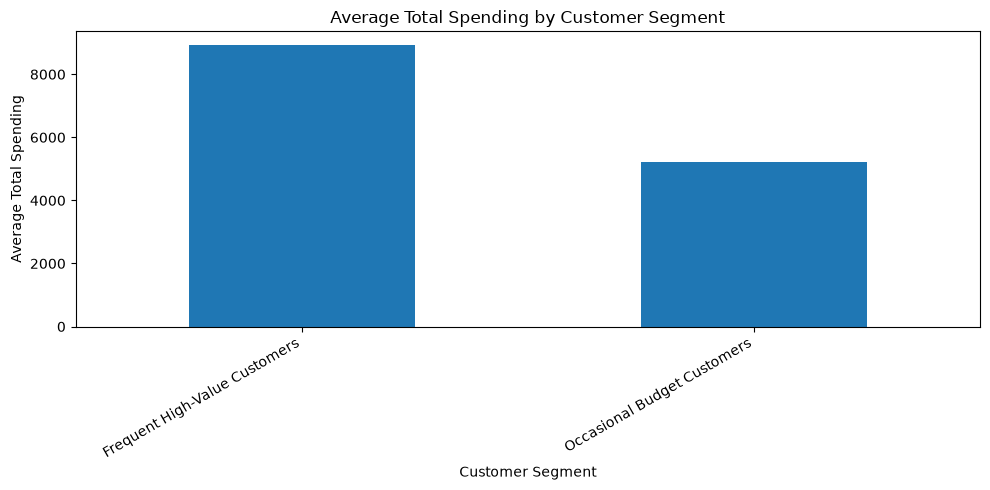

In [13]:
import matplotlib.pyplot as plt

# Customer segment comparison
customer_plot = (
    customer_segmentation
    .groupby("customer_segment_name")["total_spending"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
customer_plot.plot(kind="bar")
plt.title("Average Total Spending by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

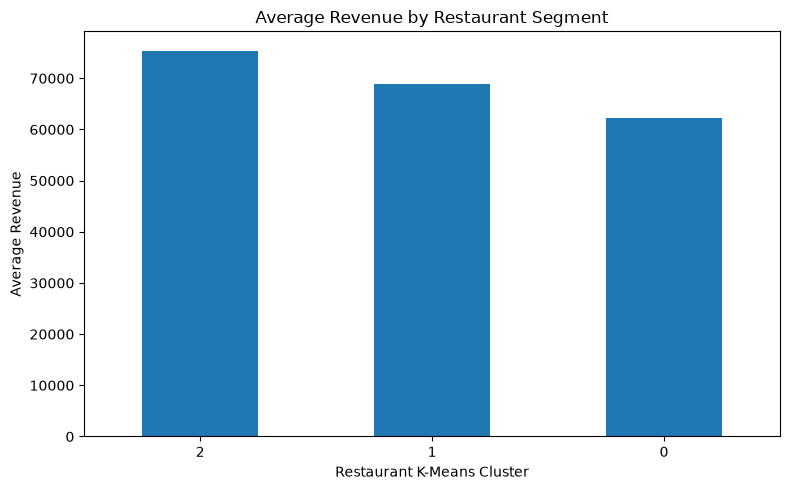

In [14]:
# Restaurant segment comparison
restaurant_plot = (
    restaurant_segmentation
    .groupby("kmeans_cluster")["revenue"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
restaurant_plot.plot(kind="bar")
plt.title("Average Revenue by Restaurant Segment")
plt.xlabel("Restaurant K-Means Cluster")
plt.ylabel("Average Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
restaurant_operational = (
    restaurant_segmentation
    .groupby("kmeans_cluster")[
        [
            "avg_rating",
            "avg_preparation_time",
            "cancellation_rate",
            "avg_delivery_time"
        ]
    ]
    .mean()
    .round(2)
)

display(restaurant_operational)

,avg_rating,avg_preparation_time,cancellation_rate,avg_delivery_time
kmeans_cluster,,,,
0,3.89,16.90,0.09,36.98
1,3.88,27.84,0.09,47.87
2,3.86,16.69,0.09,36.67


### Interpretation

Customer segmentation is interpreted through differences in spending and ordering behavior across clusters.

Restaurant segmentation is interpreted through operational characteristics such as revenue, ratings, preparation time, cancellation rate, and delivery time.

These profiles allow the business to identify:

- High-value customer segments for retention
- High-performing restaurant segments
- Restaurant segments with operational weaknesses
- Areas where restaurant intervention may improve customer experience

## 14. Sentiment Analysis – Negative Customer Themes

The NLP model identified the main themes associated with negative customer experiences.

In the integrated pipeline, we reproduce these themes from the review data so that the Day 6 notebook remains independently reproducible.

The analysis focuses on:

- Packaging issues
- Food quality
- Poor experience
- Delivery delays

In [16]:
# Load the review dataset

reviews = pd.read_csv(
    "../data/raw/reviews.csv"
)

print("Reviews shape:", reviews.shape)
print("Columns:", reviews.columns.tolist())

Reviews shape: (43996, 7)
Columns: ['review_id', 'order_id', 'customer_id', 'restaurant_id', 'rating', 'review_text', 'review_timestamp']


In [17]:
# Recreate sentiment labels from customer ratings

def create_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

reviews["sentiment"] = reviews["rating"].apply(create_sentiment)

print(reviews["sentiment"].value_counts())

sentiment
positive    30843
neutral      7512
negative     5641
Name: count, dtype: int64


In [18]:
# Analyze major complaint themes among negative reviews

negative_reviews = reviews[
    reviews["sentiment"] == "negative"
].copy()

negative_text = negative_reviews["review_text"].fillna("").str.lower()

complaint_themes = {
    "Packaging Issues": r"packag|package",
    "Food Quality": r"quality|food quality",
    "Poor Experience": r"disappoint|poor|bad experience",
    "Delivery Delays": r"late|delay|delayed"
}

theme_counts = {}

for theme, pattern in complaint_themes.items():
    theme_counts[theme] = negative_text.str.contains(
        pattern,
        regex=True,
        na=False
    ).sum()

complaint_summary = (
    pd.DataFrame(
        list(theme_counts.items()),
        columns=["Theme", "Review Count"]
    )
    .sort_values("Review Count", ascending=False)
)

display(complaint_summary)

,Theme,Review Count
2,Poor Experience,1676
3,Delivery Delays,1158
1,Food Quality,558
0,Packaging Issues,550


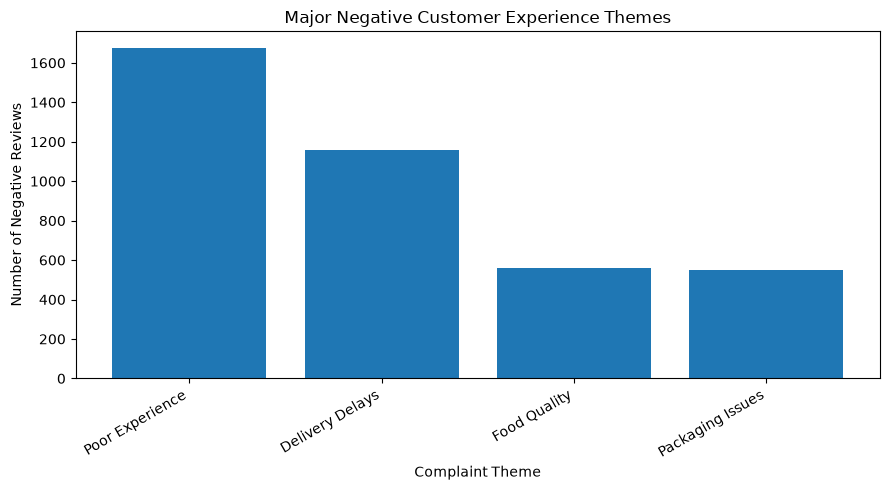

In [19]:
# Visualize the major negative customer themes

plt.figure(figsize=(9, 5))

plt.bar(
    complaint_summary["Theme"],
    complaint_summary["Review Count"]
)

plt.title("Major Negative Customer Experience Themes")
plt.xlabel("Complaint Theme")
plt.ylabel("Number of Negative Reviews")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### NLP Business Insight

Negative customer feedback is concentrated around operational and restaurant-quality issues.

The major themes identified from negative reviews provide actionable areas for improvement:

- Packaging issues → improve restaurant packaging standards
- Food quality → investigate recurring restaurant quality problems
- Poor experience → identify restaurants or orders associated with repeated dissatisfaction
- Delivery delays → connect customer feedback with delivery-time and traffic conditions

This demonstrates how NLP can convert unstructured customer comments into operational business signals.

## 4. Delivery Time Prediction

The Day 4 regression analysis focused on predicting `delivery_duration_min`.

### Features Used

The model incorporated operational and order-related features including:

- Delivery distance
- Order amount
- Number of items
- Preparation time
- Restaurant rating
- Order hour
- Day of week
- Weekend indicator
- Weather condition
- Traffic condition
- Time of day

### Model Comparison

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Linear Regression | 3.188 | 3.970 | 0.8992 |
| Random Forest | 3.403 | 4.237 | 0.8852 |
| Ridge | 3.188 | 3.970 | 0.8992 |
| Lasso | 3.188 | 3.970 | 0.8992 |

### Model Interpretation

The regression models produced very similar results, with Linear Regression, Ridge, and Lasso performing slightly better than Random Forest on the test set.

The best-performing models achieved:

- MAE of approximately 3.19 minutes
- RMSE of approximately 3.97 minutes
- R² of approximately 0.90

This indicates that the selected features explain a large proportion of the variation in delivery duration for this dataset.

### Business Insight

Delivery duration is influenced by a combination of order, restaurant, and operational conditions.

The prediction model can be used as an early-warning mechanism to identify orders that are likely to take longer than expected.

This is particularly relevant because **delivery delays were also identified as a major customer complaint theme in the NLP analysis**.

Therefore, the two ML components can be connected:

**Customer Feedback → identifies delivery delays as a complaint**

↓

**Delivery Prediction Model → helps identify orders at risk of longer delivery times**

↓

**Operations Team → can take preventive action before the delay occurs**

Potential operational actions include:

- Prioritizing high-risk deliveries
- Monitoring preparation delays
- Allocating riders based on expected delivery demand
- Investigating high-traffic periods
- Monitoring long-distance orders

In [20]:
# Check available processed outputs

import os

processed_files = os.listdir("../data/processed")

for file in processed_files:
    print(file)

customer_segmentation.csv
customer_features.csv
demand_forecast_7_days.csv
hourly_demand.csv
restaurant_segmentation.csv


In [21]:
# Day 4 - Delivery Time Prediction Model Comparison

delivery_model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Ridge",
        "Lasso"
    ],
    "MAE": [
        3.187982,
        3.402696,
        3.187980,
        3.187644
    ],
    "RMSE": [
        3.970435,
        4.236611,
        3.970432,
        3.969839
    ],
    "R2": [
        0.899194,
        0.885225,
        0.899194,
        0.899224
    ]
})

delivery_model_results

,Model,MAE,RMSE,R2
0,Linear Regression,3.187982,3.970435,0.899194
1,Random Forest,3.402696,4.236611,0.885225
2,Ridge,3.187980,3.970432,0.899194
3,Lasso,3.187644,3.969839,0.899224


In [22]:
# Select the model with the lowest MAE

best_delivery_model = delivery_model_results.loc[
    delivery_model_results["MAE"].idxmin()
]

print("Best Delivery Time Prediction Model:")
print(best_delivery_model)

Best Delivery Time Prediction Model:
Model       Lasso
MAE      3.187644
RMSE     3.969839
R2       0.899224
Name: 3, dtype: object


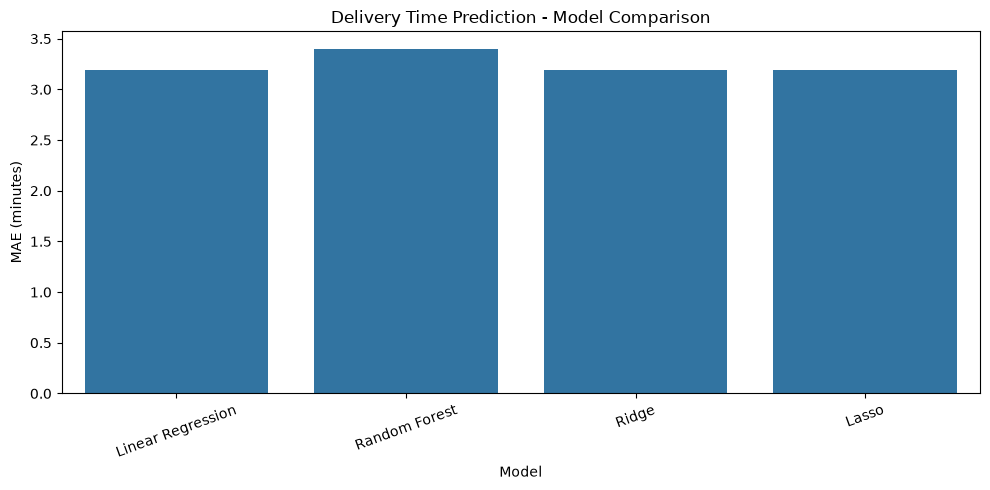

In [24]:
import seaborn as sns
plt.figure(figsize=(10, 5))

sns.barplot(
    data=delivery_model_results,
    x="Model",
    y="MAE"
)

plt.title("Delivery Time Prediction - Model Comparison")
plt.xlabel("Model")
plt.ylabel("MAE (minutes)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Delivery Prediction – Business Interpretation

The Day 4 regression models achieved an MAE of approximately 3.19 minutes for the best-performing model.

Lasso achieved the lowest MAE and RMSE, with an R² of approximately 0.90. However, the performance difference between Lasso, Ridge, and Linear Regression is extremely small.

Random Forest performed slightly worse on the test dataset.

### Business Insight

The delivery prediction model can be used to identify orders that are expected to take longer to deliver.

This becomes particularly valuable when combined with:

- Demand forecasting
- Traffic conditions
- Weather conditions
- Delivery distance
- Restaurant preparation time

The model can therefore support proactive delivery operations rather than reacting only after a delivery becomes late.

In [26]:
# Load the 7-day demand forecast generated in Day 5

forecast_7_days = pd.read_csv(
    "../data/processed/demand_forecast_7_days.csv"
)

print("Forecast shape:", forecast_7_days.shape)
forecast_7_days.head()

Forecast shape: (168, 4)


,forecast_timestamp,predicted_orders,lower_bound,upper_bound
0,2026-08-01 00:00:00,5.865879,2.735939,8.855825
1,2026-08-01 01:00:00,5.857208,2.710169,8.719812
2,2026-08-01 02:00:00,5.845116,2.753047,8.974902
3,2026-08-01 03:00:00,5.832649,2.885658,9.120201
4,2026-08-01 04:00:00,5.813418,2.915659,9.038552


In [27]:
print("Forecast columns:")
print(forecast_7_days.columns.tolist())

Forecast columns:
['forecast_timestamp', 'predicted_orders', 'lower_bound', 'upper_bound']


In [29]:
# Identify the predicted demand peak

peak_forecast = forecast_7_days.loc[
    forecast_7_days["predicted_orders"].idxmax()
]

print("Predicted peak demand:")
print(peak_forecast)

Predicted peak demand:
forecast_timestamp    2026-08-04 18:00:00
predicted_orders                 6.001165
lower_bound                      2.981083
upper_bound                      9.052149
Name: 90, dtype: object


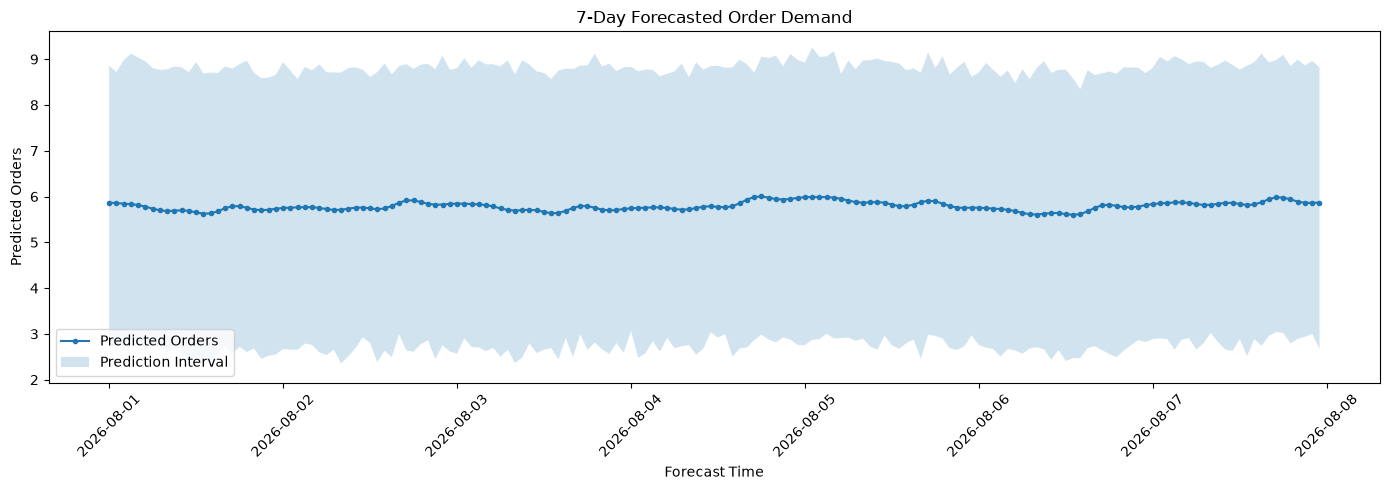

In [33]:
# Convert forecast timestamp to datetime
forecast_7_days["forecast_timestamp"] = pd.to_datetime(
    forecast_7_days["forecast_timestamp"]
)

# Plot forecast with readable timestamps
plt.figure(figsize=(14, 5))

plt.plot(
    forecast_7_days["forecast_timestamp"],
    forecast_7_days["predicted_orders"],
    marker="o",
    markersize=3,
    label="Predicted Orders"
)

plt.fill_between(
    forecast_7_days["forecast_timestamp"],
    forecast_7_days["lower_bound"],
    forecast_7_days["upper_bound"],
    alpha=0.2,
    label="Prediction Interval"
)

plt.title("7-Day Forecasted Order Demand")
plt.xlabel("Forecast Time")
plt.ylabel("Predicted Orders")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# Find the highest predicted demand period

peak_index = forecast_7_days["predicted_orders"].idxmax()

peak_time = forecast_7_days.loc[
    peak_index, "forecast_timestamp"
]

peak_demand = forecast_7_days.loc[
    peak_index, "predicted_orders"
]

print("Peak predicted demand:")
print("Time:", peak_time)
print("Predicted orders:", round(peak_demand, 2))

Peak predicted demand:
Time: 2026-08-04 18:00:00
Predicted orders: 6.0


In [35]:
# Understand how much demand varies during the forecast period

average_demand = forecast_7_days["predicted_orders"].mean()
minimum_demand = forecast_7_days["predicted_orders"].min()
maximum_demand = forecast_7_days["predicted_orders"].max()

print("Average predicted demand:", round(average_demand, 2))
print("Minimum predicted demand:", round(minimum_demand, 2))
print("Maximum predicted demand:", round(maximum_demand, 2))
print(
    "Peak above average:",
    round(maximum_demand - average_demand, 2)
)

Average predicted demand: 5.79
Minimum predicted demand: 5.6
Maximum predicted demand: 6.0
Peak above average: 0.21


## Demand Forecast Business Insight

The 7-day demand forecast shows relatively stable expected order volume.

- Average predicted demand: 5.79 orders
- Minimum predicted demand: 5.60 orders
- Maximum predicted demand: 6.00 orders
- Peak predicted demand: 6.00 orders
- Peak period: August 4, 2026 at 18:00
- Peak above average: 0.21 orders

The forecast therefore does not indicate a major demand surge. Instead, demand remains relatively consistent throughout the forecast period, with a modest increase around the evening peak.

From an operational perspective, the business should focus on maintaining sufficient delivery capacity during the highest-demand periods rather than making a large temporary increase in rider capacity.

## Integrated Customer Experience and Operations Insight

The results from Days 3, 4, and 5 can be connected to provide a single operational view.

### Day 3 – Customer Feedback

Sentiment analysis showed that negative customer experiences include complaints related to delivery delays.

### Day 4 – Delivery Time Prediction

The delivery-time prediction model achieved approximately 3.19 minutes MAE and an R² of approximately 0.90, providing a useful estimate of delivery duration.

### Day 5 – Demand Forecasting

The demand forecast predicts relatively stable order volume, with the highest predicted demand of 6.00 orders occurring on August 4, 2026 at 18:00.

### Combined Business Insight

Although the forecast does not indicate a significant demand spike, the evening period with the highest predicted demand can still be monitored closely.

Combining demand forecasts with delivery-time predictions allows operations teams to identify periods where delivery capacity may come under pressure.

This is particularly relevant because delivery delays are already associated with negative customer experiences in the sentiment analysis.

### Recommended Action

Maintain adequate rider availability during forecasted high-demand periods and monitor operational factors such as traffic, preparation time, and delivery distance.

The objective is to proactively manage delivery capacity and reduce the likelihood of delivery delays, thereby improving customer experience.

## Connecting Customer Feedback with Delivery Operations

The sentiment analysis from Day 3 identified delivery-related issues as an important source of negative customer experiences.

Day 4 provides an operational perspective by analyzing factors associated with delivery duration.

The Day 4 analysis showed that delivery duration is related to factors such as:

- Delivery distance
- Restaurant preparation time
- Traffic conditions
- Weather conditions

This creates an important connection between what customers experience and what may be happening operationally.

### Customer Experience → Operational Drivers

The relationship can be interpreted as:

**Operational factors**
→ Longer preparation / greater distance / difficult traffic / adverse weather

↓

**Longer delivery duration**

↓

**Higher probability of delivery delay**

↓

**Negative customer experience**

This means that customer feedback can be used together with operational ML models to identify areas where delivery performance can be improved.

In [37]:
# Create a simple summary of the operational factors
# identified during Day 4 analysis

delivery_factors = pd.DataFrame({
    "Factor": [
        "Delivery Distance",
        "Preparation Time",
        "Traffic Condition",
        "Weather Condition"
    ],
    "Business_Role": [
        "Longer distance can increase delivery duration",
        "Longer preparation can delay order pickup",
        "Higher traffic conditions are associated with longer delivery duration",
        "Adverse weather conditions can increase delivery duration"
    ]
})

delivery_factors

,Factor,Business_Role
0,Delivery Distance,Longer distance can increase delivery duration
1,Preparation Time,Longer preparation can delay order pickup
2,Traffic Condition,Higher traffic conditions are associated with ...
3,Weather Condition,Adverse weather conditions can increase delive...


## Integrated Business Insight

The combined analysis suggests that delivery delays should not be treated only as a customer-service problem.

They can also be viewed as an operational problem.

Customer feedback identifies the problem from the customer's perspective, while the delivery-time analysis helps identify operational conditions that may contribute to longer delivery times.

Therefore, Uber Eats can use both sources of information:

- **Sentiment analysis** to understand customer pain points.
- **Delivery-time prediction** to anticipate potentially longer deliveries.
- **Demand forecasting** to understand expected order pressure.

Together, these models support proactive operational decision-making.

## Example Operational Decision

Suppose demand is expected to be relatively high during an evening period.

Before that period, operations can monitor:

1. Expected order demand from the forecasting model.
2. Delivery distance of incoming orders.
3. Restaurant preparation time.
4. Traffic conditions.
5. Weather conditions.
6. Predicted delivery duration.

If several risk factors occur together, the business can prioritize operational intervention before delays become widespread.

This creates a proactive workflow:

**Forecast demand → Monitor operational risk → Predict delivery duration → Take action → Monitor customer feedback**

## Customer and Restaurant Segmentation Insights

Day 2 segmentation provides a behavioral view of both customers and restaurants.

Instead of treating all customers and restaurants equally, segmentation allows the business to identify groups with different levels of value, engagement, and performance.

These segments can then be combined with the customer feedback, delivery prediction, and demand forecasting results to support targeted business decisions.

In [38]:
# Load the existing Day 2 segmentation outputs

customer_segmentation = pd.read_csv(
    "../data/processed/customer_segmentation.csv"
)

restaurant_segmentation = pd.read_csv(
    "../data/processed/restaurant_segmentation.csv"
)

print("Customer segmentation shape:", customer_segmentation.shape)
print("Restaurant segmentation shape:", restaurant_segmentation.shape)

print("\nCustomer segmentation columns:")
print(customer_segmentation.columns.tolist())

print("\nRestaurant segmentation columns:")
print(restaurant_segmentation.columns.tolist())

Customer segmentation shape: (5000, 13)
Restaurant segmentation shape: (500, 11)

Customer segmentation columns:
['customer_id', 'total_orders', 'avg_order_value', 'total_spending', 'ordering_frequency', 'avg_rating_given', 'weekend_orders', 'late_night_orders', 'cluster', 'cluster_name', 'dbscan_cluster', 'kmeans_cluster', 'customer_segment_name']

Restaurant segmentation columns:
['restaurant_id', 'total_orders', 'revenue', 'avg_rating', 'avg_preparation_time', 'cancellation_rate', 'avg_delivery_time', 'kmeans_cluster', 'PC1', 'PC2', 'dbscan_cluster']


,customer_id,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders,cluster,cluster_name,dbscan_cluster,kmeans_cluster,customer_segment_name
0,10001,15,522.848667,7842.73,1.250000,3.800000,9.0,5.0,1,Frequent High-Value Customers,-1,1,Frequent High-Value Customers
1,10002,11,730.369091,8034.06,0.916667,3.625000,5.0,4.0,1,Frequent High-Value Customers,0,1,Frequent High-Value Customers
2,10003,5,675.226000,3376.13,0.416667,4.666667,1.0,0.0,0,Occasional Moderate-Value Customers,0,0,Occasional Budget Customers
3,10004,13,622.011538,8086.15,1.083333,3.545455,5.0,4.0,1,Frequent High-Value Customers,0,1,Frequent High-Value Customers
4,10005,11,506.166364,5567.83,0.916667,3.100000,3.0,5.0,1,Frequent High-Value Customers,0,1,Frequent High-Value Customers


,restaurant_id,total_orders,revenue,avg_rating,avg_preparation_time,cancellation_rate,avg_delivery_time,kmeans_cluster,PC1,PC2,dbscan_cluster
0,20001,95,65105.00,3.932584,14.011789,0.052632,33.902632,0,-1.565903,-0.748154,0
1,20002,98,71444.00,3.901099,16.278776,0.071429,36.254490,2,-1.070603,0.081272,0
2,20003,104,65223.33,3.922222,28.241538,0.096154,47.695385,1,1.420758,-0.054970,0
3,20004,87,62620.15,3.786667,27.757011,0.103448,48.555057,1,1.420826,-1.482030,0
4,20005,77,53204.10,3.647887,20.707662,0.064935,40.096494,0,-0.264234,-3.066456,-1
